In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rayleigh

In [2]:
# Настройки
np.random.seed(42)          # Для воспроизводимости результатов
sigma = 1.0
Ns = [1000, 5000, 10000]    # Объёмы выборок

# Генерация псевдослучайных чисел методом обратной функции
samples = {}
for n in Ns:
    gamma = np.random.rand(n)
    samples[n] = sigma * np.sqrt(-2 * np.log(gamma))

print("Генерация выборок завершена")

Генерация выборок завершена


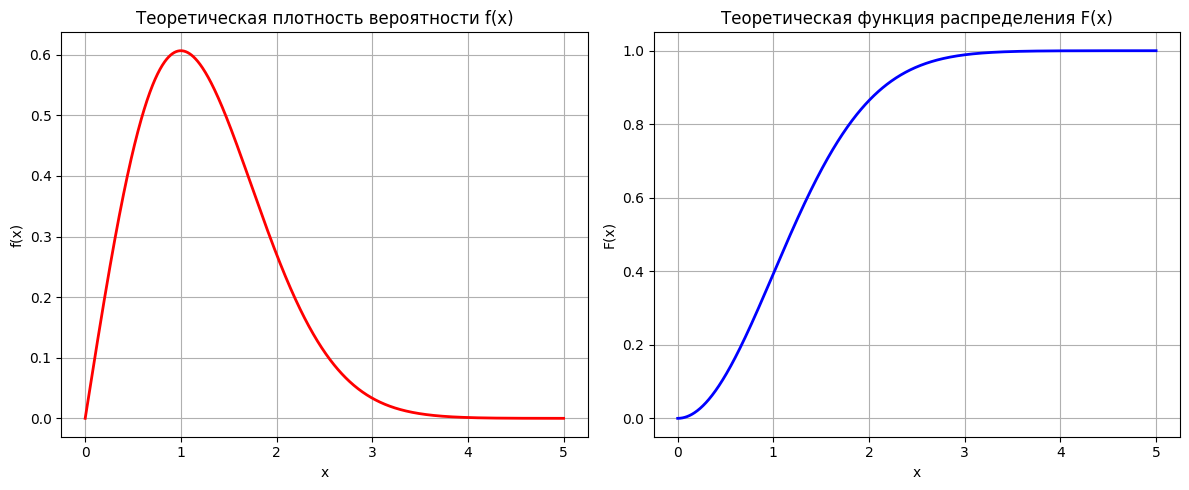

In [3]:
x = np.linspace(0, 5, 1000)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(x, rayleigh.pdf(x, scale=sigma), 'r-', lw=2)
plt.title('Теоретическая плотность вероятности f(x)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(x, rayleigh.cdf(x, scale=sigma), 'b-', lw=2)
plt.title('Теоретическая функция распределения F(x)')
plt.xlabel('x')
plt.ylabel('F(x)')
plt.grid(True)

plt.tight_layout()
plt.show()

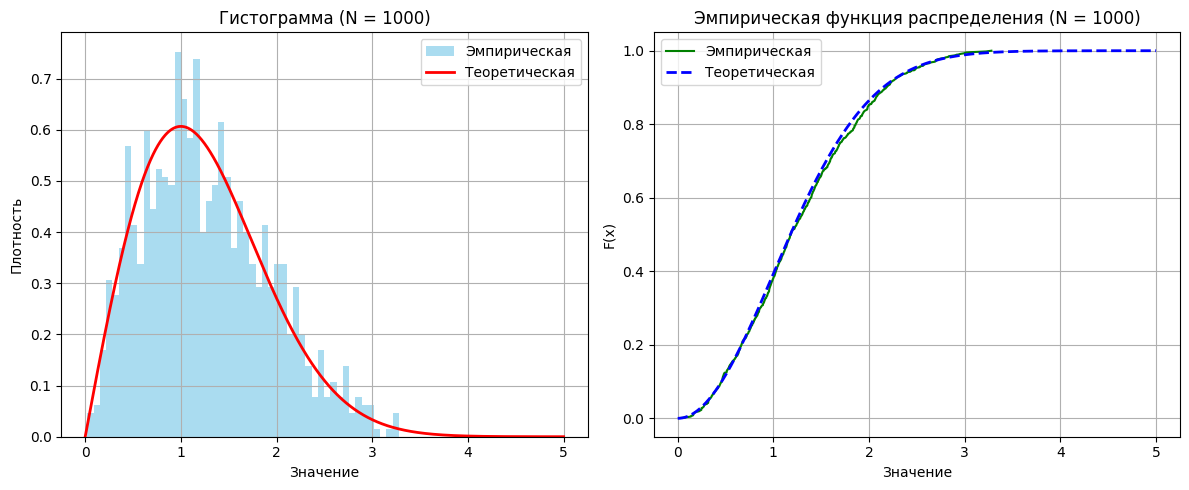

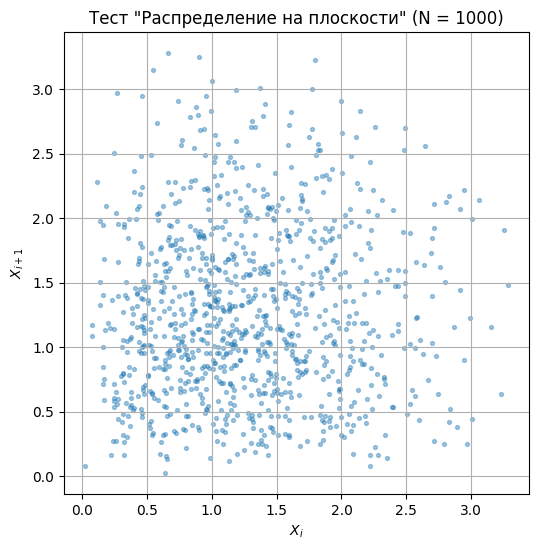

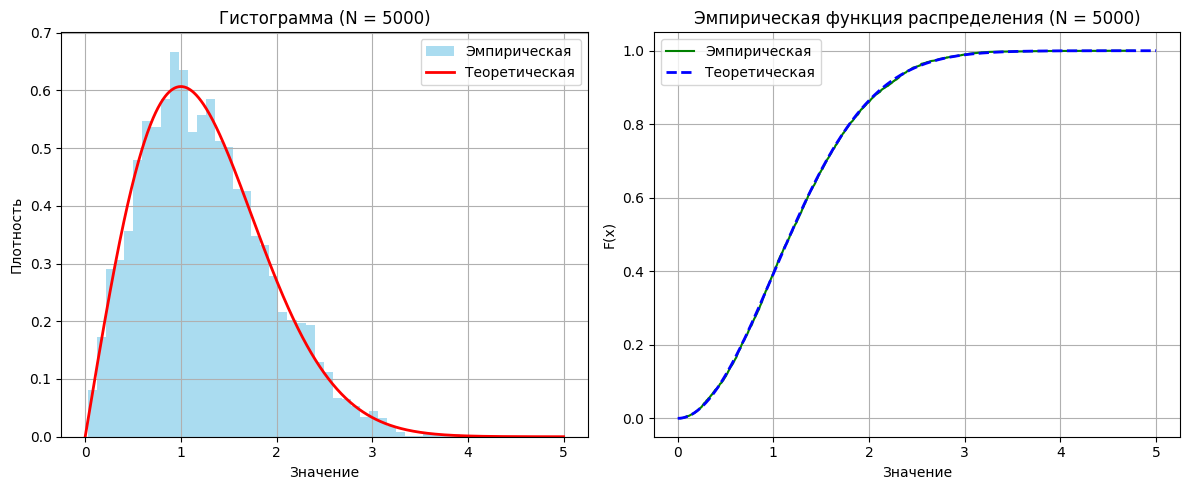

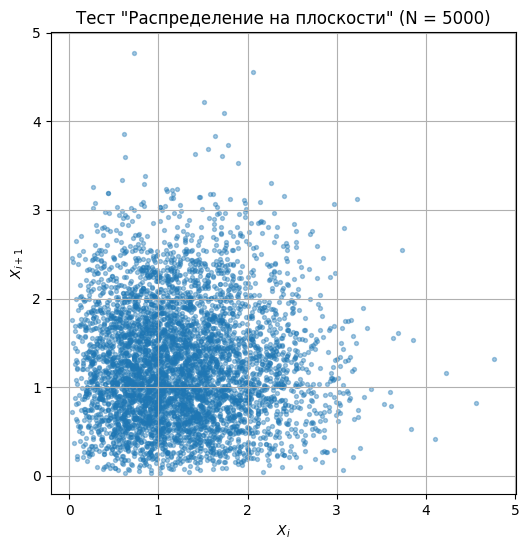

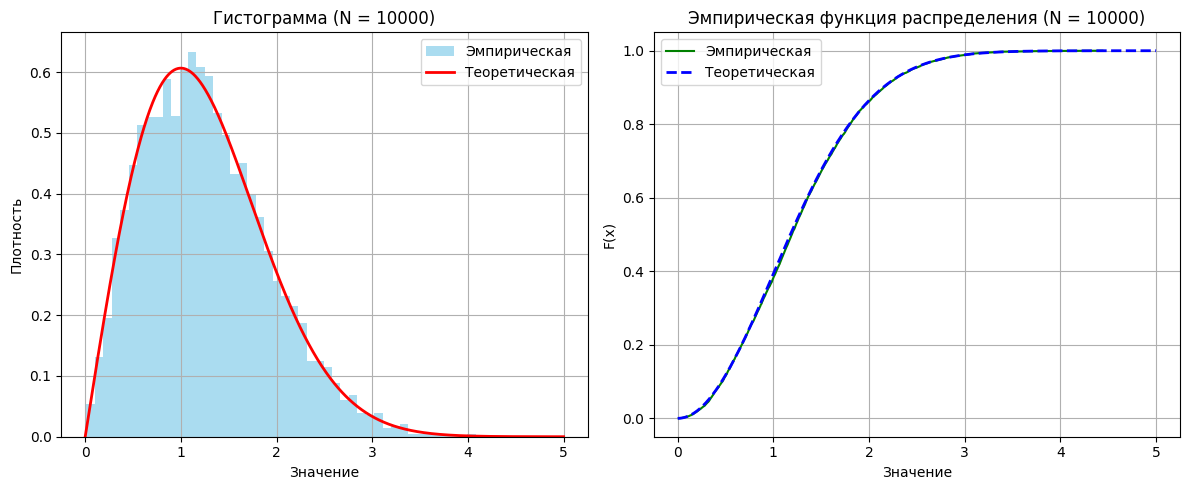

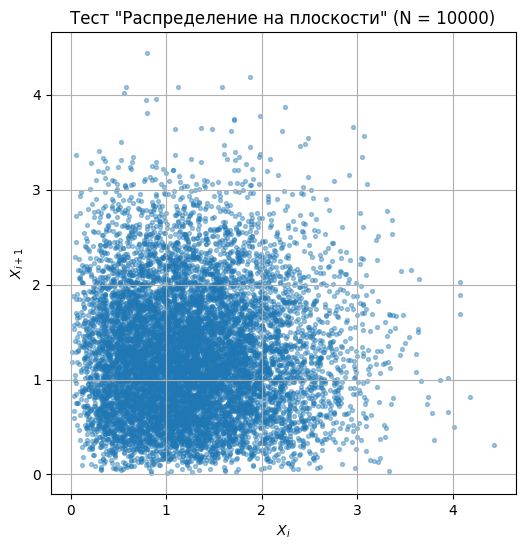

In [4]:
for n in Ns:
    data = samples[n]
    
    # Гистограмма + теоретическая плотность
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.hist(data, bins=50, density=True, alpha=0.7, color='skyblue', label='Эмпирическая')
    plt.plot(x, rayleigh.pdf(x, scale=sigma), 'r-', lw=2, label='Теоретическая')
    plt.title(f'Гистограмма (N = {n})')
    plt.xlabel('Значение')
    plt.ylabel('Плотность')
    plt.grid(True)
    plt.legend()
    
    # Эмпирическая функция распределения
    plt.subplot(1, 2, 2)
    sorted_data = np.sort(data)
    emp_cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    plt.plot(sorted_data, emp_cdf, 'g-', label='Эмпирическая')
    plt.plot(x, rayleigh.cdf(x, scale=sigma), 'b--', lw=2, label='Теоретическая')
    plt.title(f'Эмпирическая функция распределения (N = {n})')
    plt.xlabel('Значение')
    plt.ylabel('F(x)')
    plt.grid(True)
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Графический тест "Распределение на плоскости"
    plt.figure(figsize=(6, 6))
    plt.scatter(data[:-1], data[1:], alpha=0.4, s=8)
    plt.title(f'Тест "Распределение на плоскости" (N = {n})')
    plt.xlabel('$X_i$')
    plt.ylabel('$X_{i+1}$')
    plt.grid(True)
    plt.show()

In [5]:
print("N\t\tСреднее\t\tДисперсия\tСКО")
for n in Ns:
    data = samples[n]
    mean_emp = np.mean(data)
    var_emp = np.var(data, ddof=1)
    std_emp = np.std(data, ddof=1)
    print(f"{n}\t\t{mean_emp:.4f}\t\t{var_emp:.4f}\t\t{std_emp:.4f}")

N		Среднее		Дисперсия	СКО
1000		1.2739		0.4304		0.6561
5000		1.2568		0.4315		0.6569
10000		1.2625		0.4298		0.6556
